In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          TD3  ·  LunarLander-v2 (continuous)  ·  TRAINING      ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import copy

# ── Config ────────────────────────────────────────────────────────────────────
STATE_DIM  = 8
ACTION_DIM = 2
MAX_ACTION = 1.0

learning_rate      = 3e-4
gamma              = 0.99
tau                = 0.005   # soft update coefficient
policy_noise       = 0.2     # target policy smoothing noise std
noise_clip         = 0.5     # target noise clipping range
policy_freq        = 2       # actor/target update delay
batch_size         = 256
buffer_size        = 1_000_000
exploration_noise  = 0.1     # Gaussian noise added during training
start_episodes     = 30      # random exploration before training (episodes)
TOTAL_EPISODES     = 4000
EVAL_INTERVAL      = 50      # evaluation period (episodes)
SAVE_INTERVAL      = 500     # FINAL_PATH 덮어쓰기 주기 (episodes)
N_EVAL_EPISODES    = 5

FINAL_PATH = 'td3_lunar_lander_final.pt'
BEST_PATH  = 'td3_lunar_lander_best.pt'
LOG_DIR    = f'runs/TD3_lunar_lander_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'CUDA   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Log dir: {LOG_DIR}')

# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self):
        self.ptr  = 0
        self.size = 0
        self.s  = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.a  = np.zeros((buffer_size, ACTION_DIM), dtype=np.float32)
        self.r  = np.zeros((buffer_size, 1),          dtype=np.float32)
        self.s_ = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.d  = np.zeros((buffer_size, 1),          dtype=np.float32)

    def add(self, s, a, r, s_, done):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s_[self.ptr] = s_
        self.d[self.ptr]  = done
        self.ptr  = (self.ptr + 1) % buffer_size
        self.size = min(self.size + 1, buffer_size)

    def sample(self):
        idx = np.random.randint(0, self.size, batch_size)
        return (
            torch.FloatTensor(self.s[idx]).to(device),
            torch.FloatTensor(self.a[idx]).to(device),
            torch.FloatTensor(self.r[idx]).to(device),
            torch.FloatTensor(self.s_[idx]).to(device),
            torch.FloatTensor(self.d[idx]).to(device),
        )

# ── Actor ─────────────────────────────────────────────────────────────────────
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, ACTION_DIM),nn.Tanh(),
        )

    def forward(self, s):
        return MAX_ACTION * self.net(s)

# ── Critic (Twin Q-networks) ──────────────────────────────────────────────────
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )
        self.q2 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=1)
        return self.q1(sa), self.q2(sa)

    def q1_forward(self, s, a):
        return self.q1(torch.cat([s, a], dim=1))

# ── TD3 Agent ─────────────────────────────────────────────────────────────────
class TD3Agent:
    def __init__(self):
        self.actor          = Actor().to(device)
        self.actor_target   = copy.deepcopy(self.actor)
        self.actor_opt      = optim.Adam(self.actor.parameters(), lr=learning_rate)

        self.critic         = Critic().to(device)
        self.critic_target  = copy.deepcopy(self.critic)
        self.critic_opt     = optim.Adam(self.critic.parameters(), lr=learning_rate)

        self.it = 0   # update iteration counter

    def select_action(self, s):
        s = torch.FloatTensor(s).unsqueeze(0).to(device)
        return self.actor(s).cpu().data.numpy().flatten()

    def update(self, buf):
        self.it += 1
        s, a, r, s_, d = buf.sample()

        with torch.no_grad():
            # Target policy smoothing
            noise       = (torch.randn_like(a) * policy_noise).clamp(-noise_clip, noise_clip)
            a_          = (self.actor_target(s_) + noise).clamp(-MAX_ACTION, MAX_ACTION)
            # Clipped Double Q
            q1_, q2_    = self.critic_target(s_, a_)
            q_target    = r + gamma * (1 - d) * torch.min(q1_, q2_)

        # ── Critic update ─────────────────────────────────────────────────────
        q1, q2      = self.critic(s, a)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        actor_loss = None
        # ── Delayed actor + target update ─────────────────────────────────────
        if self.it % policy_freq == 0:
            actor_loss = -self.critic.q1_forward(s, self.actor(s)).mean()
            self.actor_opt.zero_grad()
            actor_loss.backward()
            self.actor_opt.step()

            # Soft update
            for p, tp in zip(self.critic.parameters(), self.critic_target.parameters()):
                tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
            for p, tp in zip(self.actor.parameters(), self.actor_target.parameters()):
                tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        return critic_loss.item(), actor_loss.item() if actor_loss else None

    def save(self, path):
        torch.save({
            'actor':         self.actor.state_dict(),
            'critic':        self.critic.state_dict(),
            'actor_target':  self.actor_target.state_dict(),
            'critic_target': self.critic_target.state_dict(),
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=device)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])
        self.actor_target.load_state_dict(ckpt['actor_target'])
        self.critic_target.load_state_dict(ckpt['critic_target'])

# ── Evaluation (no noise, no render) ─────────────────────────────────────────
def evaluate(agent):
    eval_env = gym.make('LunarLander-v2', continuous=True)
    
    rewards  = []
    for _ in range(N_EVAL_EPISODES):
        s, _     = eval_env.reset()
        done     = False
        ep_r     = 0.0
        while not done:
            a        = agent.select_action(s)
            s, r, done, truncated, _ = eval_env.step(a)
            done     = done or truncated
            ep_r    += r
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

# ── Main Training Loop ────────────────────────────────────────────────────────
def main():
    env    = gym.make('LunarLander-v2', continuous=True)
    buf    = ReplayBuffer()
    agent  = TD3Agent()
    writer = SummaryWriter(log_dir=LOG_DIR)

    best_eval = float('-inf')

    print(f'\n{"="*58}')
    print(f'  TD3  |  LunarLander-v2 continuous')
    print(f'  Total episodes  : {TOTAL_EPISODES:,}')
    print(f'  Random explore  : first {start_episodes} episodes')
    print(f'  Eval interval   : every {EVAL_INTERVAL} episodes  ({N_EVAL_EPISODES} episodes)')
    print(f'{"="*58}')

    for n_epi in range(TOTAL_EPISODES):
        s, _        = env.reset()
        ep_reward   = 0.0
        ep_c_losses = []
        ep_a_losses = []

        while True:
            # ── Action selection ──────────────────────────────────────────────
            if n_epi < start_episodes:
                a = env.action_space.sample()
            else:
                a = agent.select_action(s)
                a = (a + np.random.normal(0, exploration_noise, ACTION_DIM)).clip(-MAX_ACTION, MAX_ACTION)

            s_, r, done, truncated, _ = env.step(a)
            terminal   = done or truncated
            ep_reward += r

            # done=True only for true termination (not time limit) for Bellman bootstrapping
            buf.add(s, a, r, s_, float(done))
            s = s_

            # ── Network update ────────────────────────────────────────────────
            if n_epi >= start_episodes and buf.size >= batch_size:
                c_loss, a_loss = agent.update(buf)
                ep_c_losses.append(c_loss)
                if a_loss is not None:
                    ep_a_losses.append(a_loss)

            if terminal:
                break

        # ── Episode end ───────────────────────────────────────────────────────
        writer.add_scalar('Reward/episode', ep_reward, n_epi)
        if ep_c_losses:
            writer.add_scalar('Loss/critic', np.mean(ep_c_losses), n_epi)
        if ep_a_losses:
            writer.add_scalar('Loss/actor',  np.mean(ep_a_losses),  n_epi)

        if n_epi % 10 == 0:
            print(f'  epi {n_epi:5d} | reward {ep_reward:8.1f}')

        # ── Evaluation ───────────────────────────────────────────────────────
        if n_epi >= start_episodes and n_epi % EVAL_INTERVAL == 0:
            avg_r = evaluate(agent)
            writer.add_scalar('Reward/eval', avg_r, n_epi)
            print(f'  [eval]  epi {n_epi:5d} | avg reward ({N_EVAL_EPISODES} ep): {avg_r:8.1f}')
            if avg_r > best_eval:
                best_eval = avg_r
                agent.save(BEST_PATH)
                print(f'  [best]  {best_eval:.1f} -> {BEST_PATH}')
            writer.add_scalar('Reward/best', best_eval, n_epi)

        # ── Periodic save ─────────────────────────────────────────────────────
        if n_epi % SAVE_INTERVAL == 0 and n_epi != 0:
            agent.save(FINAL_PATH)
            print(f'  [saved] epi {n_epi:,} -> {FINAL_PATH}')

    env.close()
    writer.close()
    agent.save(FINAL_PATH)
    print(f'\nTraining done.')
    print(f'  Final -> {FINAL_PATH}')
    print(f'  Best  -> {BEST_PATH}  (eval reward: {best_eval:.1f})')
    print(f'  TensorBoard: tensorboard --logdir {LOG_DIR}')

main()

Device : cuda
CUDA   : True
GPU    : NVIDIA GeForce RTX 4090
Log dir: runs/TD3_lunar_lander_20260517_003331

  TD3  |  LunarLander-v2 continuous
  Total episodes  : 4,000
  Random explore  : first 30 episodes
  Eval interval   : every 50 episodes  (5 episodes)
  epi     0 | reward   -343.0
  epi    10 | reward   -271.2
  epi    20 | reward    -67.3
  epi    30 | reward   -138.9
  epi    40 | reward    -90.8
  epi    50 | reward   -211.4
  [eval]  epi    50 | avg reward (5 ep):   -234.5
  [best]  -234.5 -> td3_lunar_lander_best.pt
  epi    60 | reward   -109.2
  epi    70 | reward    -20.2
  epi    80 | reward   -123.2
  epi    90 | reward   -104.7
  epi   100 | reward   -132.4
  [eval]  epi   100 | avg reward (5 ep):    -88.7
  [best]  -88.7 -> td3_lunar_lander_best.pt
  epi   110 | reward   -176.0
  epi   120 | reward    -37.5
  epi   130 | reward    -74.3
  epi   140 | reward   -106.1
  epi   150 | reward   -233.6
  [eval]  epi   150 | avg reward (5 ep):   -130.2
  epi   160 | reward

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_35748\183231340.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(save_path, map_location=devic

[final] actor loaded from td3_lunar_lander_final.pt
Running 5 episodes...

Episode  1/5 | reward:    294.7 | steps: 219


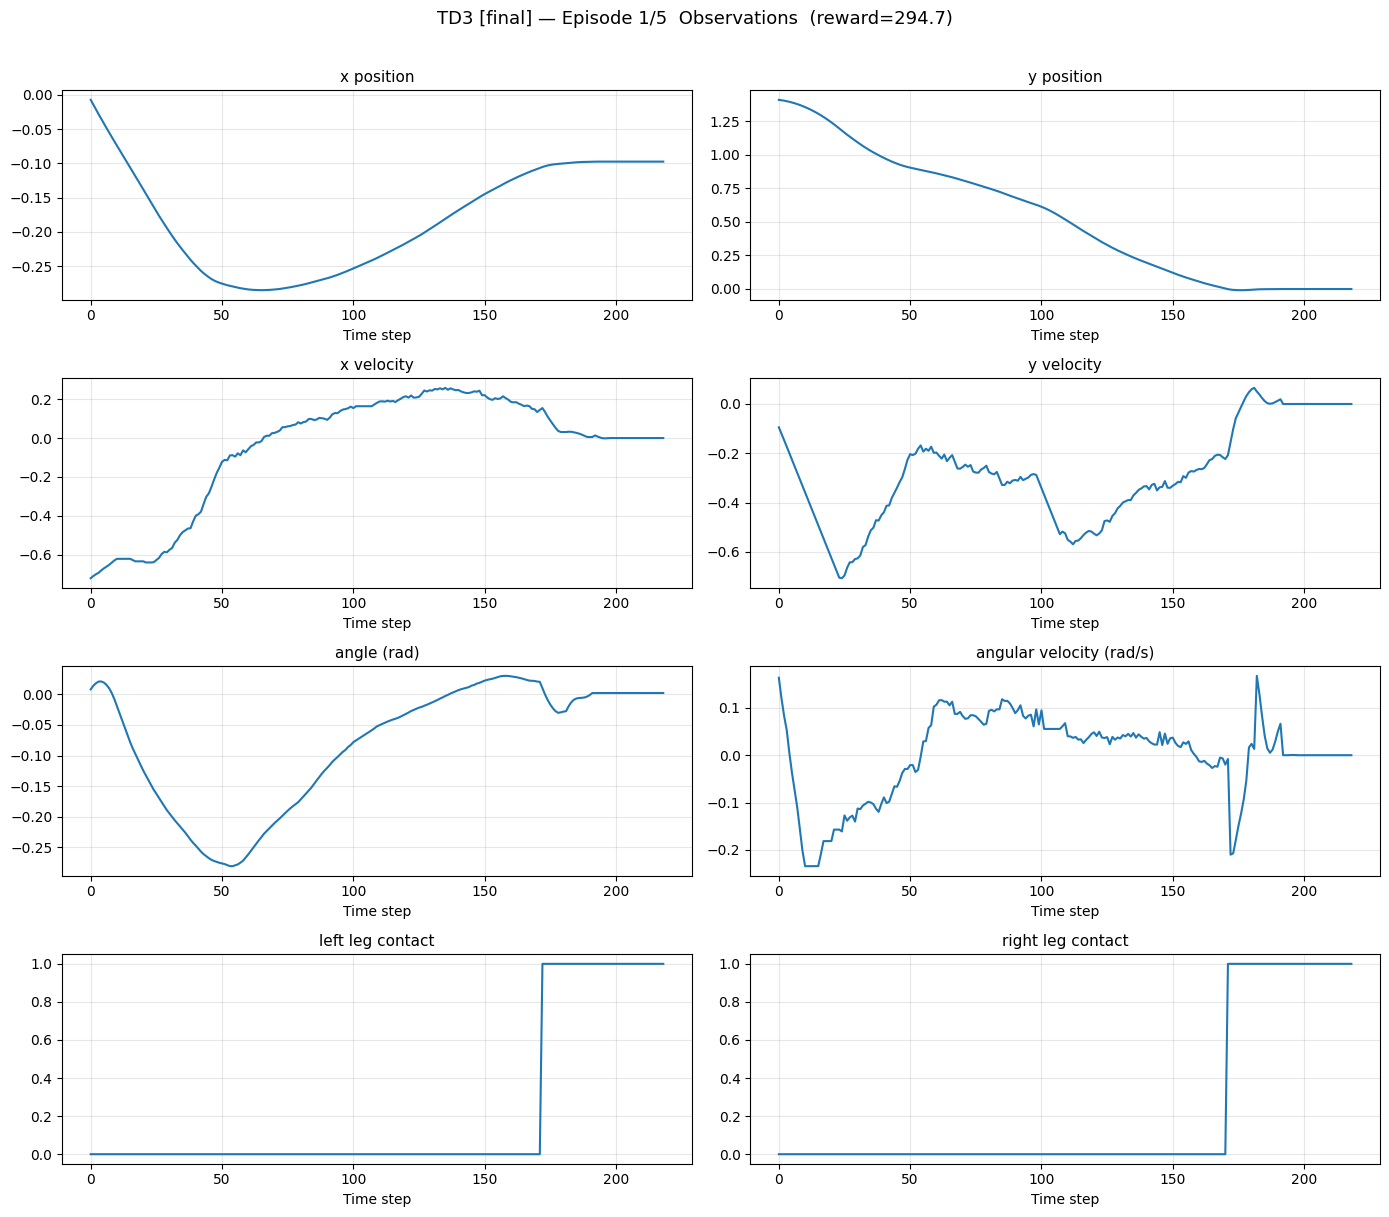

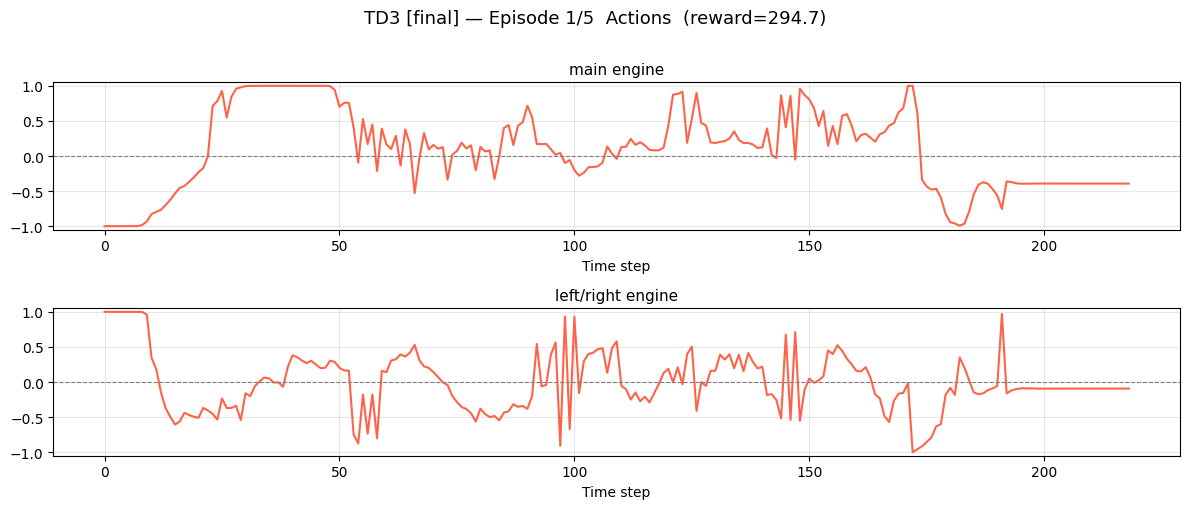

  Obs  plot -> td3_final_obs_ep1.png
  Act  plot -> td3_final_act_ep1.png

Episode  2/5 | reward:    258.6 | steps: 167


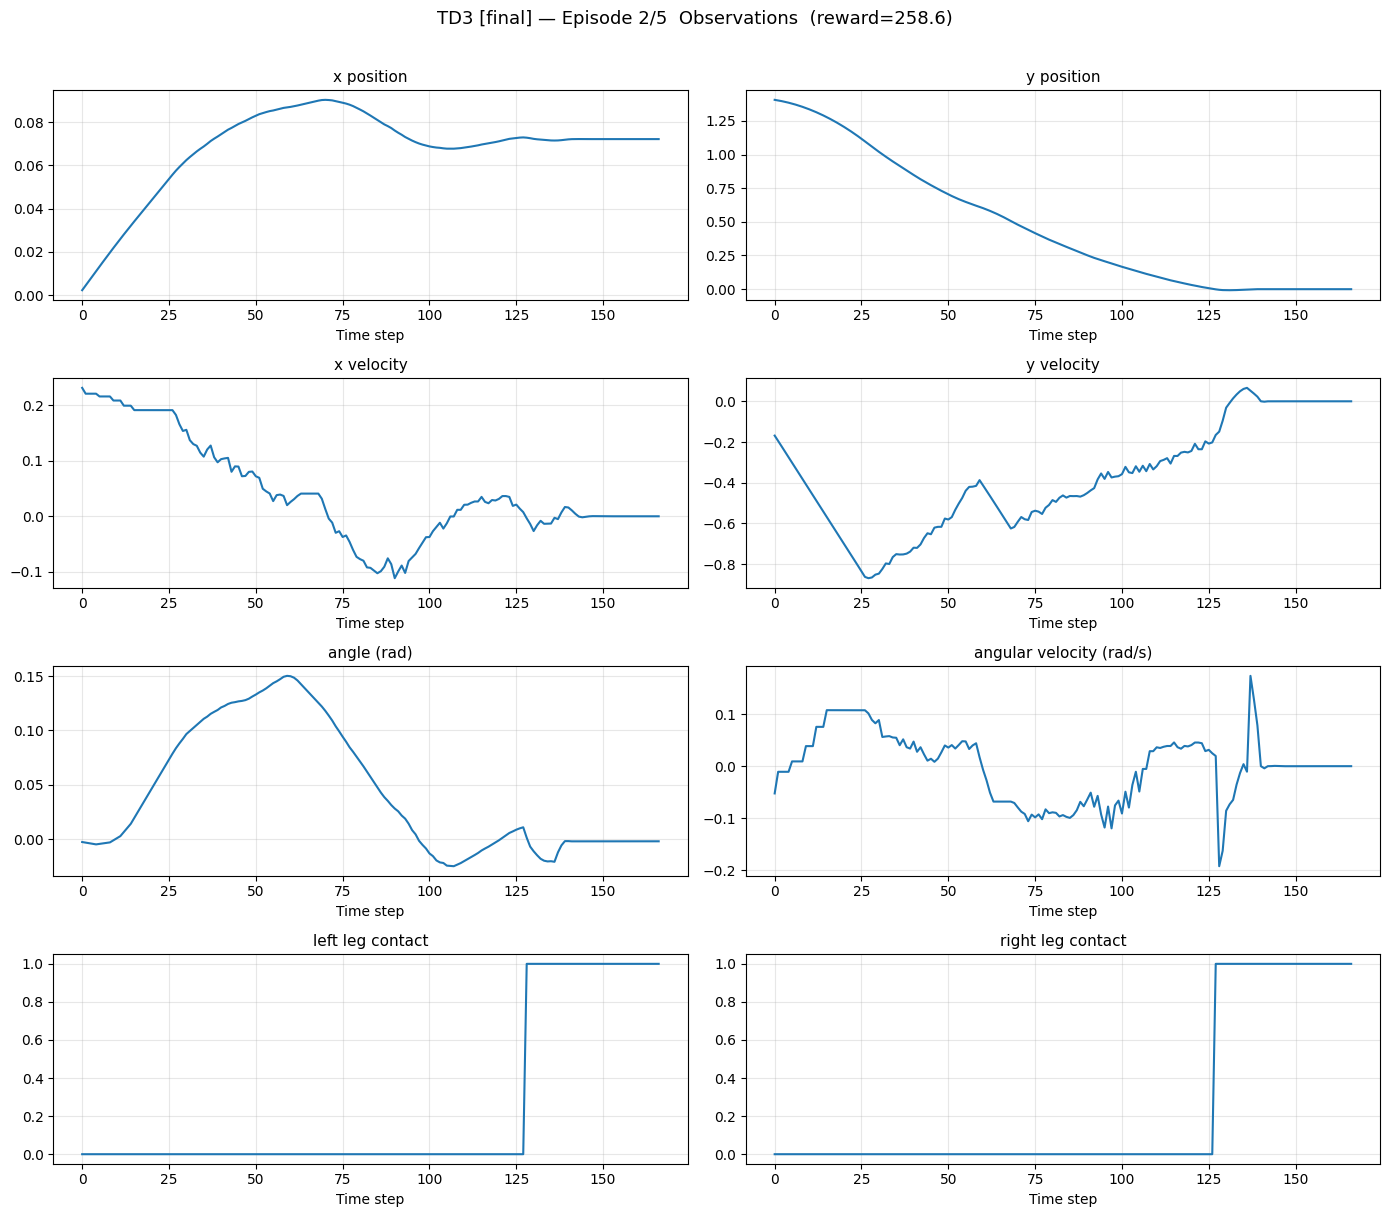

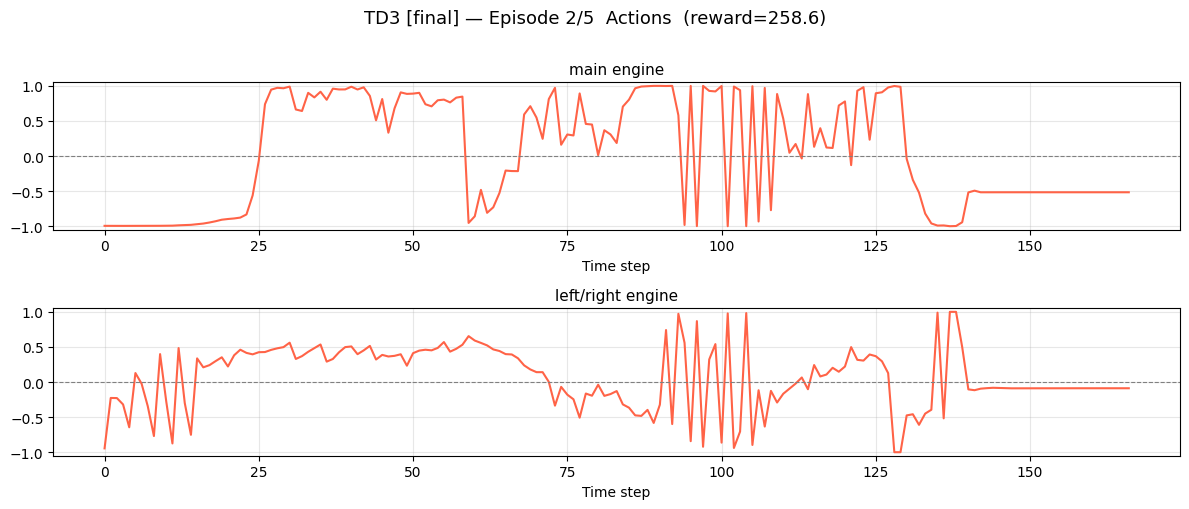

  Obs  plot -> td3_final_obs_ep2.png
  Act  plot -> td3_final_act_ep2.png

Episode  3/5 | reward:    267.1 | steps: 181


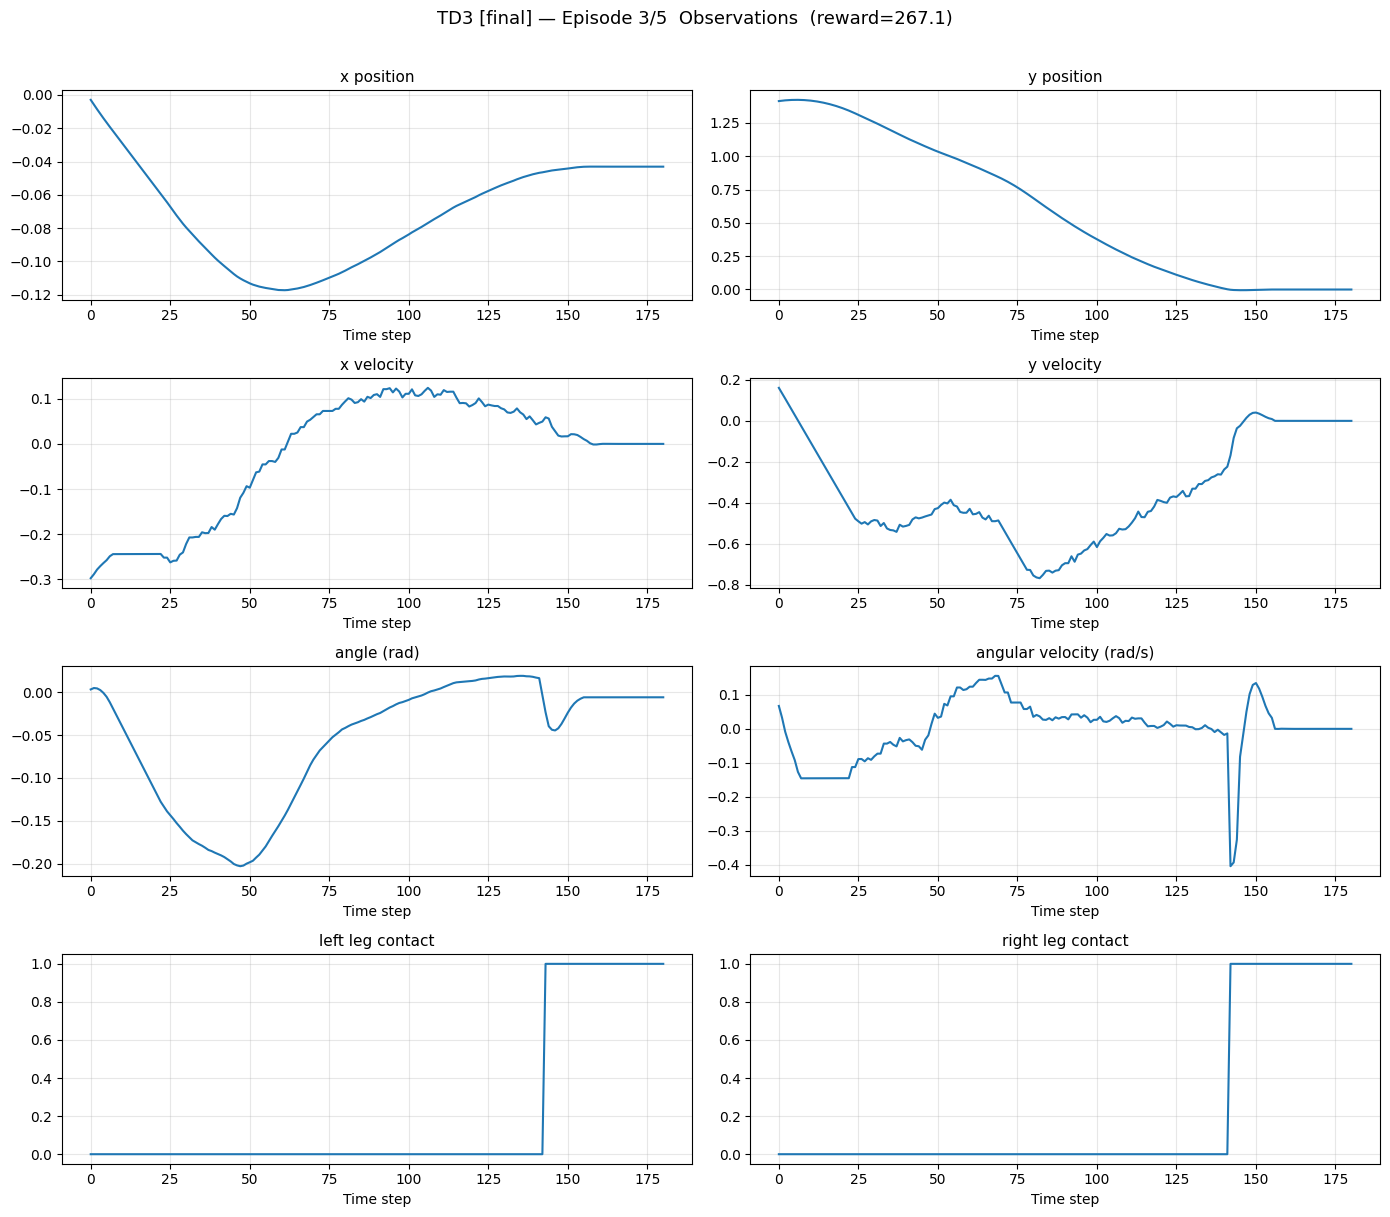

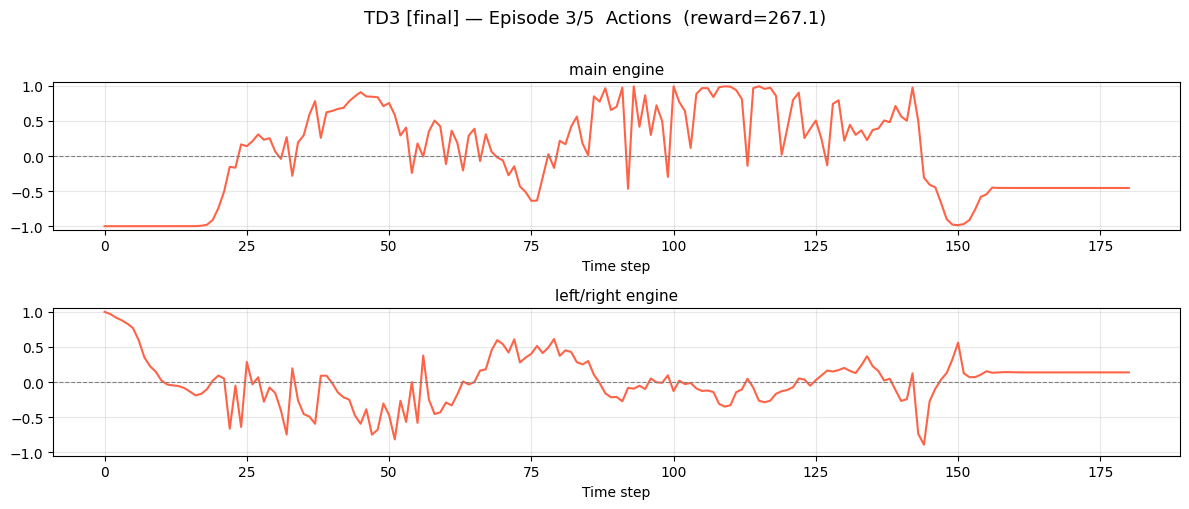

  Obs  plot -> td3_final_obs_ep3.png
  Act  plot -> td3_final_act_ep3.png

Episode  4/5 | reward:    275.7 | steps: 203


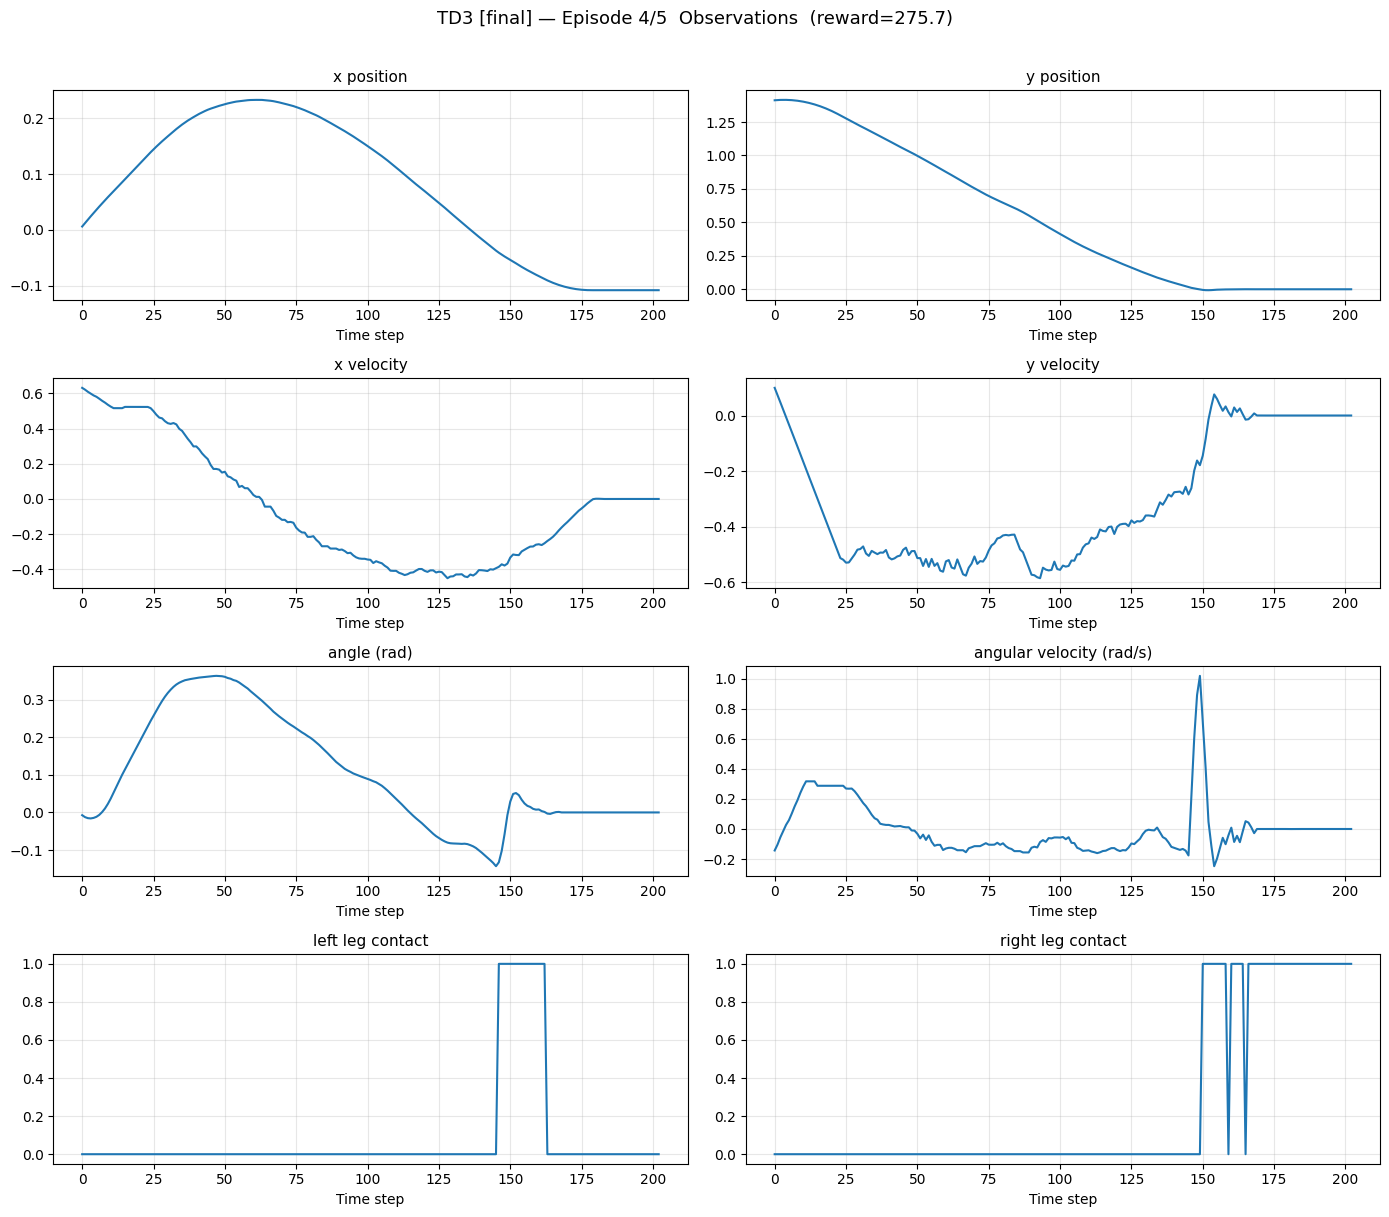

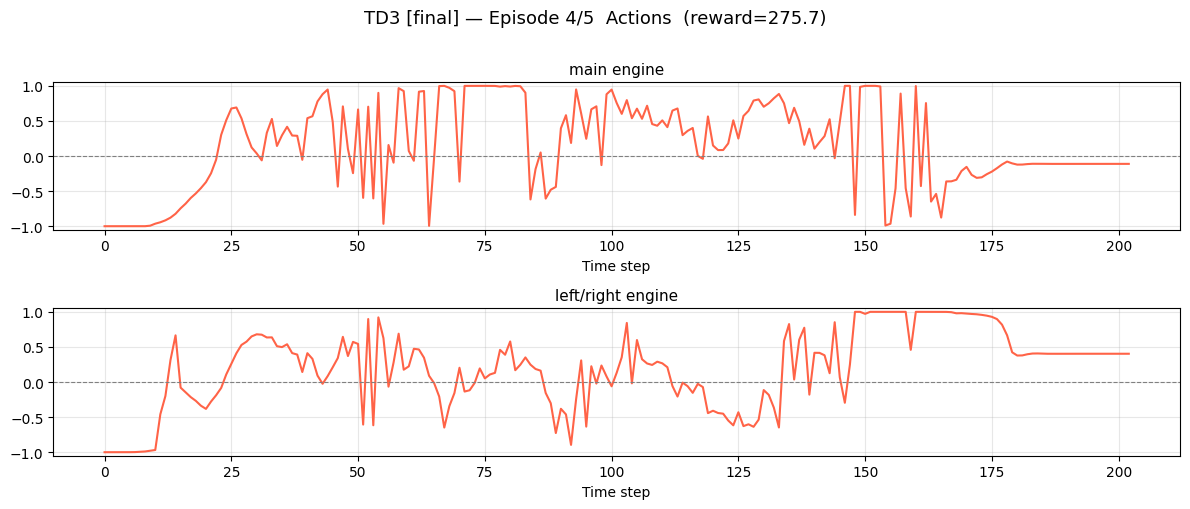

  Obs  plot -> td3_final_obs_ep4.png
  Act  plot -> td3_final_act_ep4.png

Episode  5/5 | reward:    288.7 | steps: 211


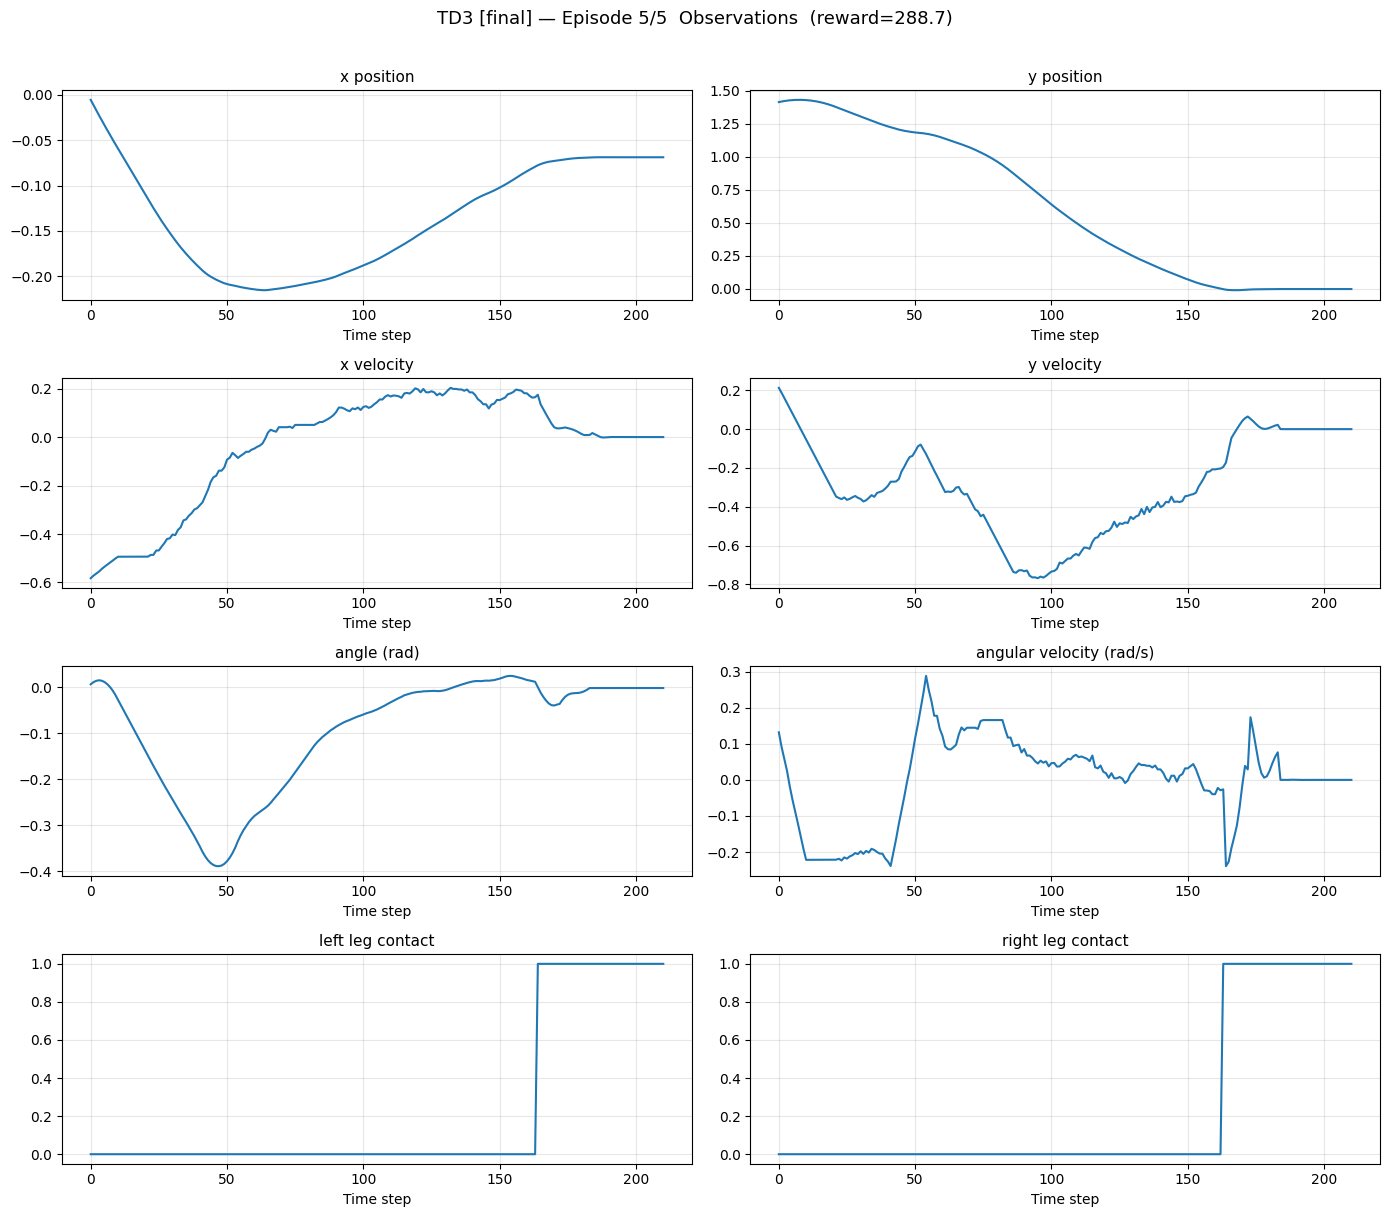

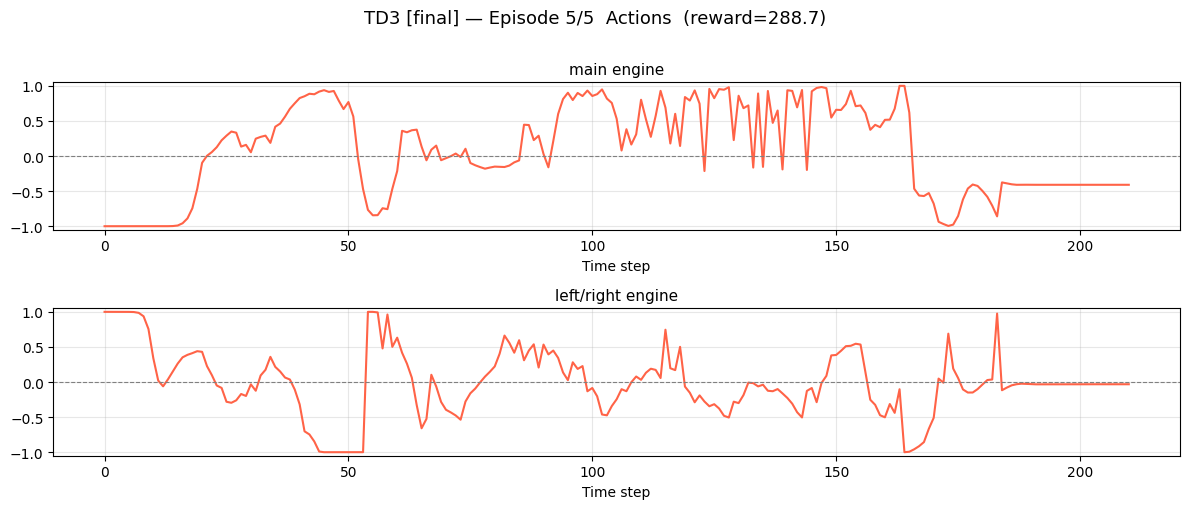

  Obs  plot -> td3_final_obs_ep5.png
  Act  plot -> td3_final_act_ep5.png

Done.


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          TD3  ·  LunarLander-v2 (continuous)  ·  INFERENCE     ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ── Config (must match training) ──────────────────────────────────────────────
STATE_DIM  = 8
ACTION_DIM = 2
MAX_ACTION = 1.0

FINAL_PATH = 'td3_lunar_lander_final.pt'
BEST_PATH  = 'td3_lunar_lander_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Actor (must match training) ───────────────────────────────────────────────
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, ACTION_DIM),nn.Tanh(),
        )

    def forward(self, s):
        return MAX_ACTION * self.net(s)

# ── Inference ─────────────────────────────────────────────────────────────────
def run_inference(save_path=FINAL_PATH, n_episodes=5):
    """
    save_path : FINAL_PATH (default) 또는 BEST_PATH
    n_episodes: 렌더링할 에피소드 수
    """
    env = gym.make('LunarLander-v2', continuous=True, render_mode='human')

    actor = Actor().to(device)
    ckpt  = torch.load(save_path, map_location=device)
    actor.load_state_dict(ckpt['actor'])
    actor.eval()

    model_tag = 'final' if save_path == FINAL_PATH else 'best'
    print(f'[{model_tag}] actor loaded from {save_path}')
    print(f'Running {n_episodes} episodes...\n')

    var_labels = [
        'x position',        'y position',
        'x velocity',        'y velocity',
        'angle (rad)',        'angular velocity (rad/s)',
        'left leg contact',  'right leg contact',
    ]
    action_labels = ['main engine', 'left/right engine']

    for ep in range(n_episodes):
        s, _         = env.reset()
        done         = False
        obs_history  = []
        act_history  = []
        total_reward = 0.0

        with torch.no_grad():
            while not done:
                obs_history.append(s.copy())
                s_t  = torch.FloatTensor(s).unsqueeze(0).to(device)
                a    = actor(s_t).cpu().numpy().flatten()
                act_history.append(a.copy())
                s, r, done, truncated, _ = env.step(a)
                done = done or truncated
                total_reward += r

        steps = len(obs_history)
        print(f'Episode {ep+1:2d}/{n_episodes} | reward: {total_reward:8.1f} | steps: {steps}')

        obs = np.array(obs_history)   # (T, 8)
        act = np.array(act_history)   # (T, 2)
        t   = np.arange(steps)

        # ── Observation plot (4×2) ────────────────────────────────────────────
        fig, axes = plt.subplots(4, 2, figsize=(14, 12))
        for ax, col, label in zip(axes.flatten(), range(8), var_labels):
            ax.plot(t, obs[:, col], linewidth=1.5)
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            f'TD3 [{model_tag}] — Episode {ep+1}/{n_episodes}  Observations  (reward={total_reward:.1f})',
            fontsize=13, y=1.01
        )
        plt.tight_layout()
        obs_path = f'td3_{model_tag}_obs_ep{ep+1}.png'
        plt.savefig(obs_path, dpi=150, bbox_inches='tight')
        plt.show()

        # ── Action plot (2×1) ─────────────────────────────────────────────────
        fig, axes = plt.subplots(2, 1, figsize=(12, 5))
        for ax, col, label in zip(axes, range(2), action_labels):
            ax.plot(t, act[:, col], linewidth=1.5, color='tomato')
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.set_ylim(-1.05, 1.05)
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            f'TD3 [{model_tag}] — Episode {ep+1}/{n_episodes}  Actions  (reward={total_reward:.1f})',
            fontsize=13, y=1.01
        )
        plt.tight_layout()
        act_path = f'td3_{model_tag}_act_ep{ep+1}.png'
        plt.savefig(act_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Obs  plot -> {obs_path}')
        print(f'  Act  plot -> {act_path}\n')

    env.close()
    print('Done.')

# ── 실행 ──────────────────────────────────────────────────────────────────────
run_inference(save_path=FINAL_PATH)     # 최종 모델, 5 에피소드
# run_inference(save_path=BEST_PATH)    # best 모델로 추론하려면 이 줄 실행